## 1) Importar bibliotecas

In [1]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import tensorflow as tf
import polars as pl
import numpy as np

## 2) Ler base de dados

In [2]:
train_df = pl.read_csv(
    source = "./dados/train_complex.csv"
)

train_df = train_df.with_columns(
    pl.lit(np.random.random(train_df.shape[0])).alias("random_column")
)

train_df = train_df.sort(
    by = "random_column"
).drop("random_column")

print(train_df.shape)
train_df.head(2)

(20000, 3)


x,y,class
f64,f64,i64
-3.87362,3.744833,0
3.194793,-0.737844,0


### 2.1) Ver quantidade de classes

In [3]:
train_df.group_by(
    "class"
).agg(
    pl.col("class").len().alias("total")
)

class,total
i64,u32
0,11579
1,8421


### 2.2) Ver distribuição das classes

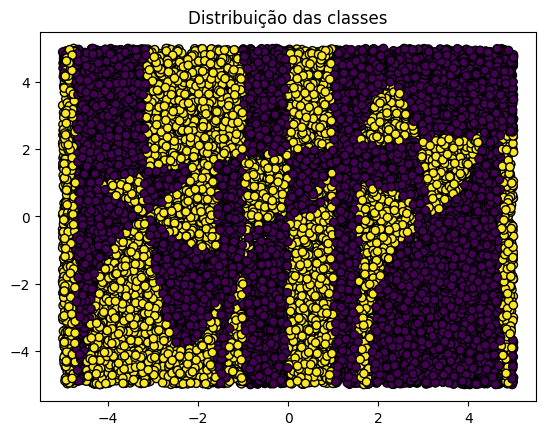

In [4]:
fig, ax = plt.subplots()

ax.scatter(
    x = train_df["x"],
    y = train_df["y"],
    c = train_df["class"],
    edgecolors = "#000"
)
ax.set_title("Distribuição das classes")

plt.show()

### 2.3) Separar dados

In [5]:
X = train_df[["x", "y"]].to_numpy()
y = train_df["class"].to_numpy()

print(X[:5])
print(y[:5])

[[-3.87361976  3.74483335]
 [ 3.19479322 -0.73784436]
 [ 3.57000795  4.04707507]
 [ 0.12897077 -3.95073076]
 [ 4.58431487 -2.14392537]]
[0 0 0 1 0]


## 3) Criar modelo

In [6]:
X.shape

(20000, 2)

### 3.1) Configurar modelo

In [7]:
neurons = 6

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape = (2, )),
    tf.keras.layers.Dense(units = 2**neurons, activation = "relu"),
    tf.keras.layers.Dense(units = 2**neurons, activation = "relu"),
    tf.keras.layers.Dense(units = 2**neurons, activation = "relu"),
    tf.keras.layers.Dense(units = 2, activation = "softmax"),
])

model_optimizer = tf.keras.optimizers.Adam()
model_loss = tf.keras.losses.SparseCategoricalCrossentropy()
model_metrics = tf.keras.metrics.SparseCategoricalCrossentropy()

model.compile(
    optimizer = model_optimizer,
    loss = model_loss,
    metrics = [model_metrics],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,642 (33.76 KB)

 Trainable params: 8,642 (33.76 KB)

 Non-trainable params: 0 (0.00 B)

### 3.2) Configurar <code>Early_stopping</code>

In [8]:
model_callback_early_stopping = tf.keras.callbacks.EarlyStopping(
    min_delta = 1E-3,
    patience = 5,
    verbose = 1,
    start_from_epoch = 200,
)

### 3.3) Treinando modelo

In [9]:
history = model.fit(
    x = X,
    y = y,
    batch_size = 512,
    epochs = 300,
    validation_split = 0.2,
    shuffle = True,
    callbacks = model_callback_early_stopping
)

Epoch 1/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.6279 - sparse_categorical_crossentropy: 0.6279 - val_loss: 0.6130 - val_sparse_categorical_crossentropy: 0.6130
Epoch 2/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6015 - sparse_categorical_crossentropy: 0.6015 - val_loss: 0.5968 - val_sparse_categorical_crossentropy: 0.5968
Epoch 3/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5905 - sparse_categorical_crossentropy: 0.5905 - val_loss: 0.5859 - val_sparse_categorical_crossentropy: 0.5859
Epoch 4/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5801 - sparse_categorical_crossentropy: 0.5801 - val_loss: 0.5743 - val_sparse_categorical_crossentropy: 0.5743
Epoch 5/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5675 - sparse_categorical_crossentropy: 0.5675 - val_loss: 0.5600 - val_sparse_categorical_crossentropy: 0.5600
Epoch 6/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5559 - sparse_categorical_crossentropy: 0.5559 - val_loss: 0.5521 - val_sp

### 3.4) Avaliando treinamento

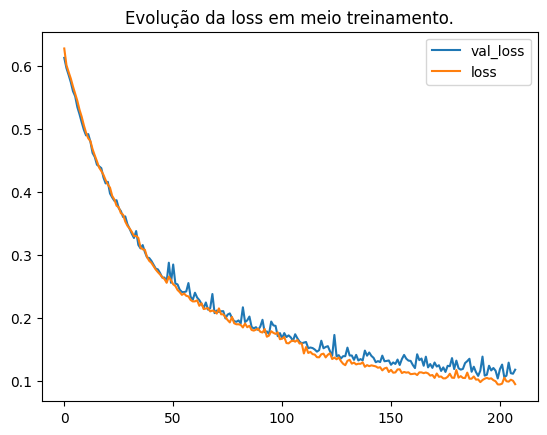

In [10]:
fig, ax = plt.subplots()

ax.plot(
    history.epoch,
    history.history["val_loss"],
    "C0",
    label = "val_loss"
)

ax.plot(
    history.epoch,
    history.history["loss"],
    "C1",
    label = "loss"
)

ax.set_title("Evolução da loss em meio treinamento.")

plt.legend()
plt.show()

### 3.5) Avaliando predição

In [11]:
X_test = pl.read_csv("./dados/test_complex.csv")

print(X_test.shape)
X_test.head(2)

(5000, 3)


x,y,class
f64,f64,i64
-2.451839,-3.967665,1
-4.077216,1.063597,1


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


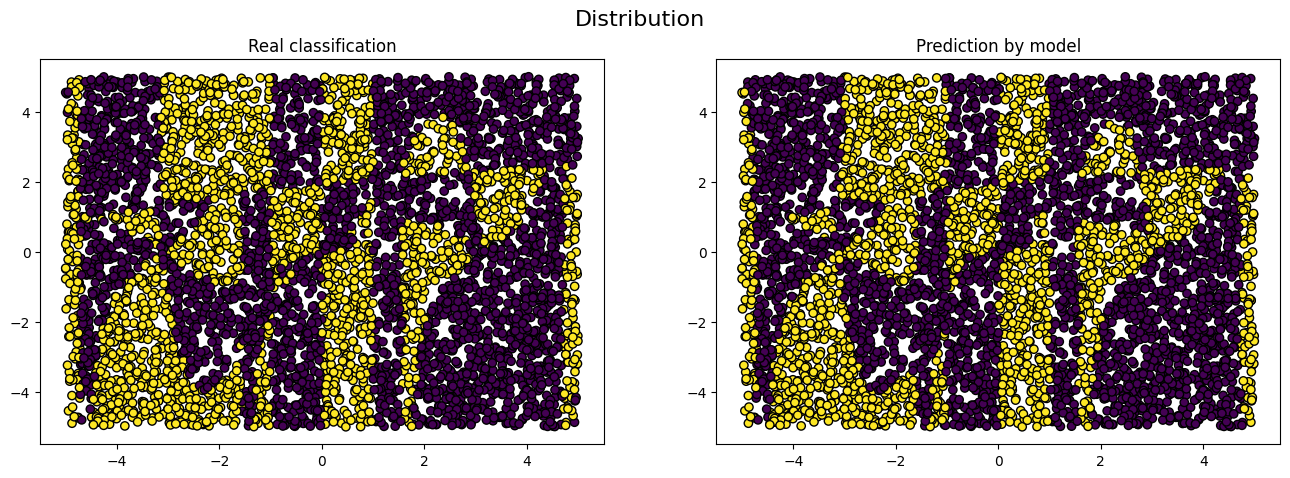

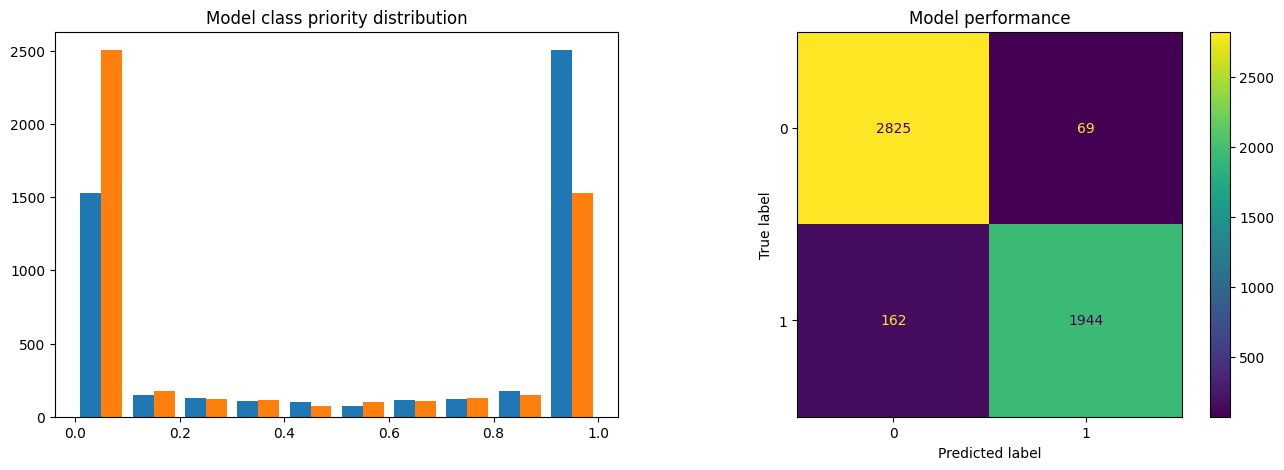

In [12]:
fig, axs = plt.subplots(
    ncols = 2,
    figsize = (16, 5)
)

ax1, ax2 = axs[0], axs[1]
predictions = model.predict(X_test[["x", "y"]].to_numpy())
prediction = predictions.argmax(axis = 1)

ax1.scatter(
    x = X_test["x"],
    y = X_test["y"],
    c = X_test["class"],
    edgecolors = "black",
)

ax2.scatter(
    x = X_test["x"],
    y = X_test["y"],
    c = prediction,
    edgecolors = "black"
)

ax1.set_title("Real classification")
ax2.set_title("Prediction by model")

plt.suptitle("Distribution", fontsize = 16)
plt.show()

fig, axs = plt.subplots(
    ncols = 2,
    figsize = (16, 5)
)

axs[0].hist(
    predictions
)

confusion_matrix_plot = ConfusionMatrixDisplay(
    confusion_matrix = confusion_matrix(y_true= X_test["class"], y_pred=prediction),
)

confusion_matrix_plot.plot(
    ax = axs[1],
    
)
axs[0].set_title("Model class priority distribution")
axs[1].set_title("Model performance")

plt.show()